# 逐 1 小时降水频率匹配订正 — 程序说明

**QPF_FM_RAIN01** 的应用场景、程序架构、算法原理与实现、配置参数及运行方式说明如下。

**核心路径**：`src/runner.py`（主程序）、`src/proc/`（核心算法）、`utils/util_env.py`（路径 ini）。命令行：`python -m cli` 或 `python src/runner.py`。

## 1. 文档与工程定位

- **程序性质**：针对**单一数值模式**逐 1 小时（1–48 h）降水预报的业务型**统计订正**流水线。利用历史同期模式–实况配对样本，在分区块内做相似个例筛选、光流位移订正与频率匹配强度订正，输出 MICAPS3 站点场与 MICAPS4 格点场。
- **设计目标**：与既有业务数据接口（MICAPS3/MICAPS4、二进制格点、NetCDF 等）对齐；在保持原 `QPFFrequencyMatch_Rain01` 算法与数值结果一致的前提下，目录布局对齐 `mait_24h`，便于维护与集成。
- **相关材料**：项目根目录 `README.md`（快速开始）；`docs/QPF_FM_RAIN01_算法说明.md`。

## 2. 应用场景

| 场景 | 说明 |
|------|------|
| **单模式 QPF 订正** | 对 ECMWF、GRAPES 等单一模式的 1 h 降水预报做后处理订正，改善 TS、频率分布与极值表现。 |
| **逐时效业务批处理** | 对每个起报时刻循环 1–48 h 预报时效；支持单时次、时次范围（步长 1 h）及多模式键（`path.json` 中 `configs`）。 |
| **空间分块订正** | 将目标区域划分为多块（短时效细分为 8×7 块，长时效为 1×1 整块），块内独立筛选样本与订正，缓解大范围单一统计关系的空间失配。 |
| **历史同期样本库** | 回溯最多 4 个日历年、在起报日 ±15 天窗口内收集模式–实况配对，构建「相似环流/相似降水型」样本池。 |
| **产品双格式输出** | MICAPS3：订正后的**站点**降水；MICAPS4：经 Cressman 插值与二次频率匹配后的**规则格点**降水。 |
| **有效区域约束** | 使用 `resource/mask010.dat` 掩膜，订正与背景场插值仅在服务区域内进行。 |

**不适用或需自行扩展的情形**：多模式集成融合；模式动力改进、新型观测质控；与默认 MICAPS 接口不同的全新数据格式。

## 3. 程序架构与模块划分

### 3.1 处理阶段划分

程序按时间尺度分为：**全局配置**（进程启动一次）→ **起报循环**（每个 `dt_input1`）→ **时效循环**（每个 `i_valid`，1–48）→ **空间分块**（每块独立订正）→ **产品写出**。

```mermaid
flowchart TB
    subgraph P0["阶段 0：任务入口"]
        A[main / process] --> B[load_path_configs / load_grid_config]
        B --> C[select_para_and_runtime]
        C --> D[生成 cycles 列表]
    end
    subgraph P1["阶段 1：起报循环 RunProcess"]
        D --> E[RunProcess.process_cycle]
        E --> F{时效 1–48 h}
    end
    subgraph P2["阶段 2：单时效 process_one_valid"]
        F --> G{输出已存在? 模式存在?}
        G -->|跳过| F
        G -->|处理| H[构建 4 年历史样本库]
        H --> I[空间分块 ThreadPool]
        I --> J[合并站点场 → MICAPS3]
        J --> K[Cressman + 频率匹配 → MICAPS4]
        K --> F
    end
    subgraph P3["阶段 3：单块 _process_block"]
        I --> L[TS+BIAS 相似筛选]
        L --> M[光流位移订正]
        M --> N[半拉格朗日平流]
        N --> O[频率匹配强度订正]
    end
```

### 3.2 目录与核心文件

| 路径 | 作用 |
|------|------|
| `cli/` | `python -m cli` 转调 `src/qpf_fm_cli.py` |
| `src/runner.py` | `main()`、`process()` |
| `src/run_config.py` | `ParaConfig`、`GridConfig`、JSON/CLI 解析 |
| `src/run_process.py` | `RunProcess`、分块订正流水线 |
| `src/proc/` | 频率匹配、TS 评分、光流、平流、Cressman |
| `utils/util_env.py` | `resource/qpf_fm.ini` 路径解析 |
| `resource/path.json` | 模式/实况/输出路径模板 |
| `resource/config.json` | 网格域、分块边界、掩膜参数 |

## 4. 算法原理

### 4.1 总体思路

数值模式 1 h 降水预报存在两类典型误差：

1. **位置误差**：雨带落区偏移；
2. **强度误差**：降水频率分布与实况不一致。

本程序采用 **「相似历史样本 + 光流平流 + 频率匹配」** 组合订正：

| 步骤 | 原理 | 作用 |
|------|------|------|
| 历史样本库 | 相近日期、相同时效的模式–实况配对 | 提供模式误差统计样本 |
| 相似个例筛选 | TS + BIAS 综合评分 | 选出最相似历史个例 |
| 光流外推 | 由历史演变场估计位移向量 | 订正雨系**位置** |
| 半拉格朗日平流 | 沿风场平流降水场 | 格点位移订正 |
| 频率匹配 | CDF 分位数映射 | 订正**强度与频率** |
| Cressman 插值 | 站点 + 背景场多尺度插值 | 生成 MICAPS4 格点产品 |

### 4.2 历史样本库构建

对每个起报时刻 `dt_input1`、预报时效 `i_valid`（1–48 h）：

- 遍历 **4 个日历年**：`y = 0, 1, 2, 3`；
- **时间窗口**：
  - `y = 0`：`[dt_input1 - 15 天, dt_input1 - 1 天]`；
  - `y > 0`：`[dt_input1 - 15 天, dt_input1 + 15 天]`；
- 模式与实况文件均存在时加入样本池，并重网格到 `config.json` 指定域（默认 0.1°）。

### 4.3 相似个例筛选（TS + BIAS）

$$TS = \frac{H}{H + M + F}, \quad BIAS = \frac{H + F}{H + M}$$

$$Score = TS + \frac{0.2}{|9 \times (BIAS - 1)| + 1}$$

在 `similar_level` 多阈值（0.1–20 mm）上平均。取前 `top_n = int(0.5 × dy)` 个样本做频率匹配；若 Score ≥ 0.3 的样本 ≥ 20，则对前 20 个估计光流。

### 4.4 光流与半拉格朗日平流

**光流**：对前 20 个历史配对，在实况 Cressman 插值场与模式场之间，由亮度恒定方程最小二乘估计 \(u, v\)，再 Cressman 插值到目标分辨率（`src/proc/optical_flow.py`）。

**半拉格朗日平流**（`src/proc/rain_extrapolation.py`）：

$$I^{new}(x, y) = I^{old}(x - u \cdot \Delta t,\; y - v \cdot \Delta t)$$

### 4.5 频率匹配（CDF Matching）

1. 实况与模式样本值分别排序（加微小随机扰动）；
2. 对每个降水等级，在实况 CDF 找分位，线性插值得模式 CDF 同分位值；
3. `correct_model_data` 分段线性映射格点值。

- 分块订正：`FACT_LEVEL`（15 档，0.1–100 mm）；
- MICAPS4：`FINAL_FACT_LEVEL`（19 档，含 0.01–250 mm）；
- `fact_level_limit=20`：CDF 两端各忽略 20 个样本。

### 4.6 空间分块与产品生成

| 预报时效 | 分块 | 说明 |
|----------|------|------|
| `i_valid ≤ 60` | 8×7 块 | `short_lon/lat_edges` |
| `i_valid > 60` | 1×1 整块 | `long_lon/lat_edges` |

订正区外扩 `expand`（默认 1.0°）作为样本区。

**MICAPS3**：合并各块站点场，< 0.01 mm 清零，写出 `.m3`。

**MICAPS4**：掩膜内背景点 + 订正站点 → Cressman（`[0.6, 0.4, 0.2, 0.1]`）→ 平滑 → 二次频率匹配 → 写出 `.m4`。

### 4.7 运行控制

| 条件 | 行为 |
|------|------|
| `.m3` 与 `.m4` 均已存在 | 跳过该时效 |
| 当前模式文件不存在 | 跳过 |
| 历史样本数 `dy = 0` | 跳过 |
| CLI 多时次 | 转为 `cycles`：`run_dt - (h+8)`，`h = 0..24` |

## 5. 算法实现与代码对应

| 算法步骤 | 实现位置 | 关键函数 |
|----------|----------|----------|
| 主入口 | `src/runner.py` | `main()`, `process()` |
| 起报循环 | `src/run_process.py` | `RunProcess.process_cycle()` |
| 单时效 | `src/run_process.py` | `process_one_valid()` |
| 单块订正 | `src/run_process.py` | `_process_block()` |
| TS+BIAS | `src/proc/ensemble.py` | `get_similarity_index_by_ts_and_bias()` |
| 光流 | `src/proc/optical_flow.py` | `get_wind_from_optical_flow()` |
| 平流 | `src/proc/rain_extrapolation.py` | `simple_semi_lagrangian_in_angle()` |
| 频率匹配 | `src/proc/frequency_match.py` | `correct_model_data()` |
| Cressman | `src/proc/spatial_analysis.py` | `gressman_interpolation_for_rain()` |

### 并行策略

| 环境变量 | 默认 | 说明 |
|----------|------|------|
| `QPF_SAMPLE_THREADS` | 4 | 历史样本加载线程 |
| `QPF_BLOCK_THREADS` | 1 | 分块订正线程 |
| `QPF_VALID_PROCESS_WORKERS` | CPU/2 | 时效并行进程（NC 模式强制 1） |
| `QPF_FIXED_RANDOM_SEED` | 无 | 频率匹配可复现 |

## 6. 配置与参数说明

### 6.1 `resource/qpf_fm.ini`

| 键 | 默认值 | 说明 |
|----|--------|------|
| `log_file` | `log/YYYYMMDD.txt` | 日志路径模板 |
| `config_json` | `resource/config.json` | 网格与分块配置 |
| `path_json` | `resource/path.json` | 数据路径模板 |
| `station_info` | `resource/sta.info` | 站点列表 |
| `mask_file` | `resource/mask010.dat` | 区域掩膜 |

### 6.2 `resource/path.json`

| 字段 | 说明 |
|------|------|
| `default` | 默认模式键 |
| `model_template` | 模式 1 h 降水路径 |
| `fact_template` | 实况 MICAPS3 路径 |
| `output_template` | 输出前缀（追加 `.m3`/`.m4`） |

**路径占位符**：`YYYY` `MM` `DD` `HH` `VVV`（预报时效，如 012）等，见 `utils/string_process.date_replace`。

### 6.3 `resource/config.json`

| 字段 | 默认 | 说明 |
|------|------|------|
| `lon/lat_start/end` | 70–140°E, 0–60°N | 目标域 |
| `dlon/dlat` | 0.1° | 网格分辨率 |
| `expand` | 1.0° | 样本区外扩 |
| `background_stride` | 5 | MICAPS4 背景采样步长 |
| `short_*_edges` | 9×8 边界点 | 短时效分块 |
| `long_*_edges` | 整域 | 长时效分块 |

### 6.4 算法内置降水等级（`src/run_config.py`）

- **FACT_LEVEL**（分块订正）：0.1, 0.5, 1, 3, 5, 7.5, 10, 15, 20, 25, 30, 40, 50, 75, 100 mm
- **SIMILAR_LEVEL**（相似度）：0.1, 0.5, 1, 3, 5, 7.5, 10, 15, 20 mm
- **FINAL_FACT_LEVEL**（MICAPS4）：0.01, 0.1, …, 250 mm（共 19 档）

### 6.5 命令行

```powershell
python -m cli
python -m cli ecmwf 202604081130
python -m cli ecmwf 202604081130 202604081800
```

## 7. 运行方式

```powershell
cd D:\Work\qpf_fm_rain01
pip install -r requirements.txt
python -m cli ecmwf 202604081130
```

运行前确认 `path.json` 路径可访问，`sta.info` 与 `mask010.dat` 存在。

| 产品 | 路径 | 格式 |
|------|------|------|
| 订正站点场 | `{output_template}.m3` | MICAPS3 |
| 订正格点场 | `{output_template}.m4` | MICAPS4 |


## 8. 与原版 QPFFrequencyMatch_Rain01 的结果ecmwf_v2对比

取相同起报时间，相同时效的QPFFrequencyMatch_Rain01结果ecmwf_v2 与 qpf_fm_rain01结果 ecmwf_nimm对比

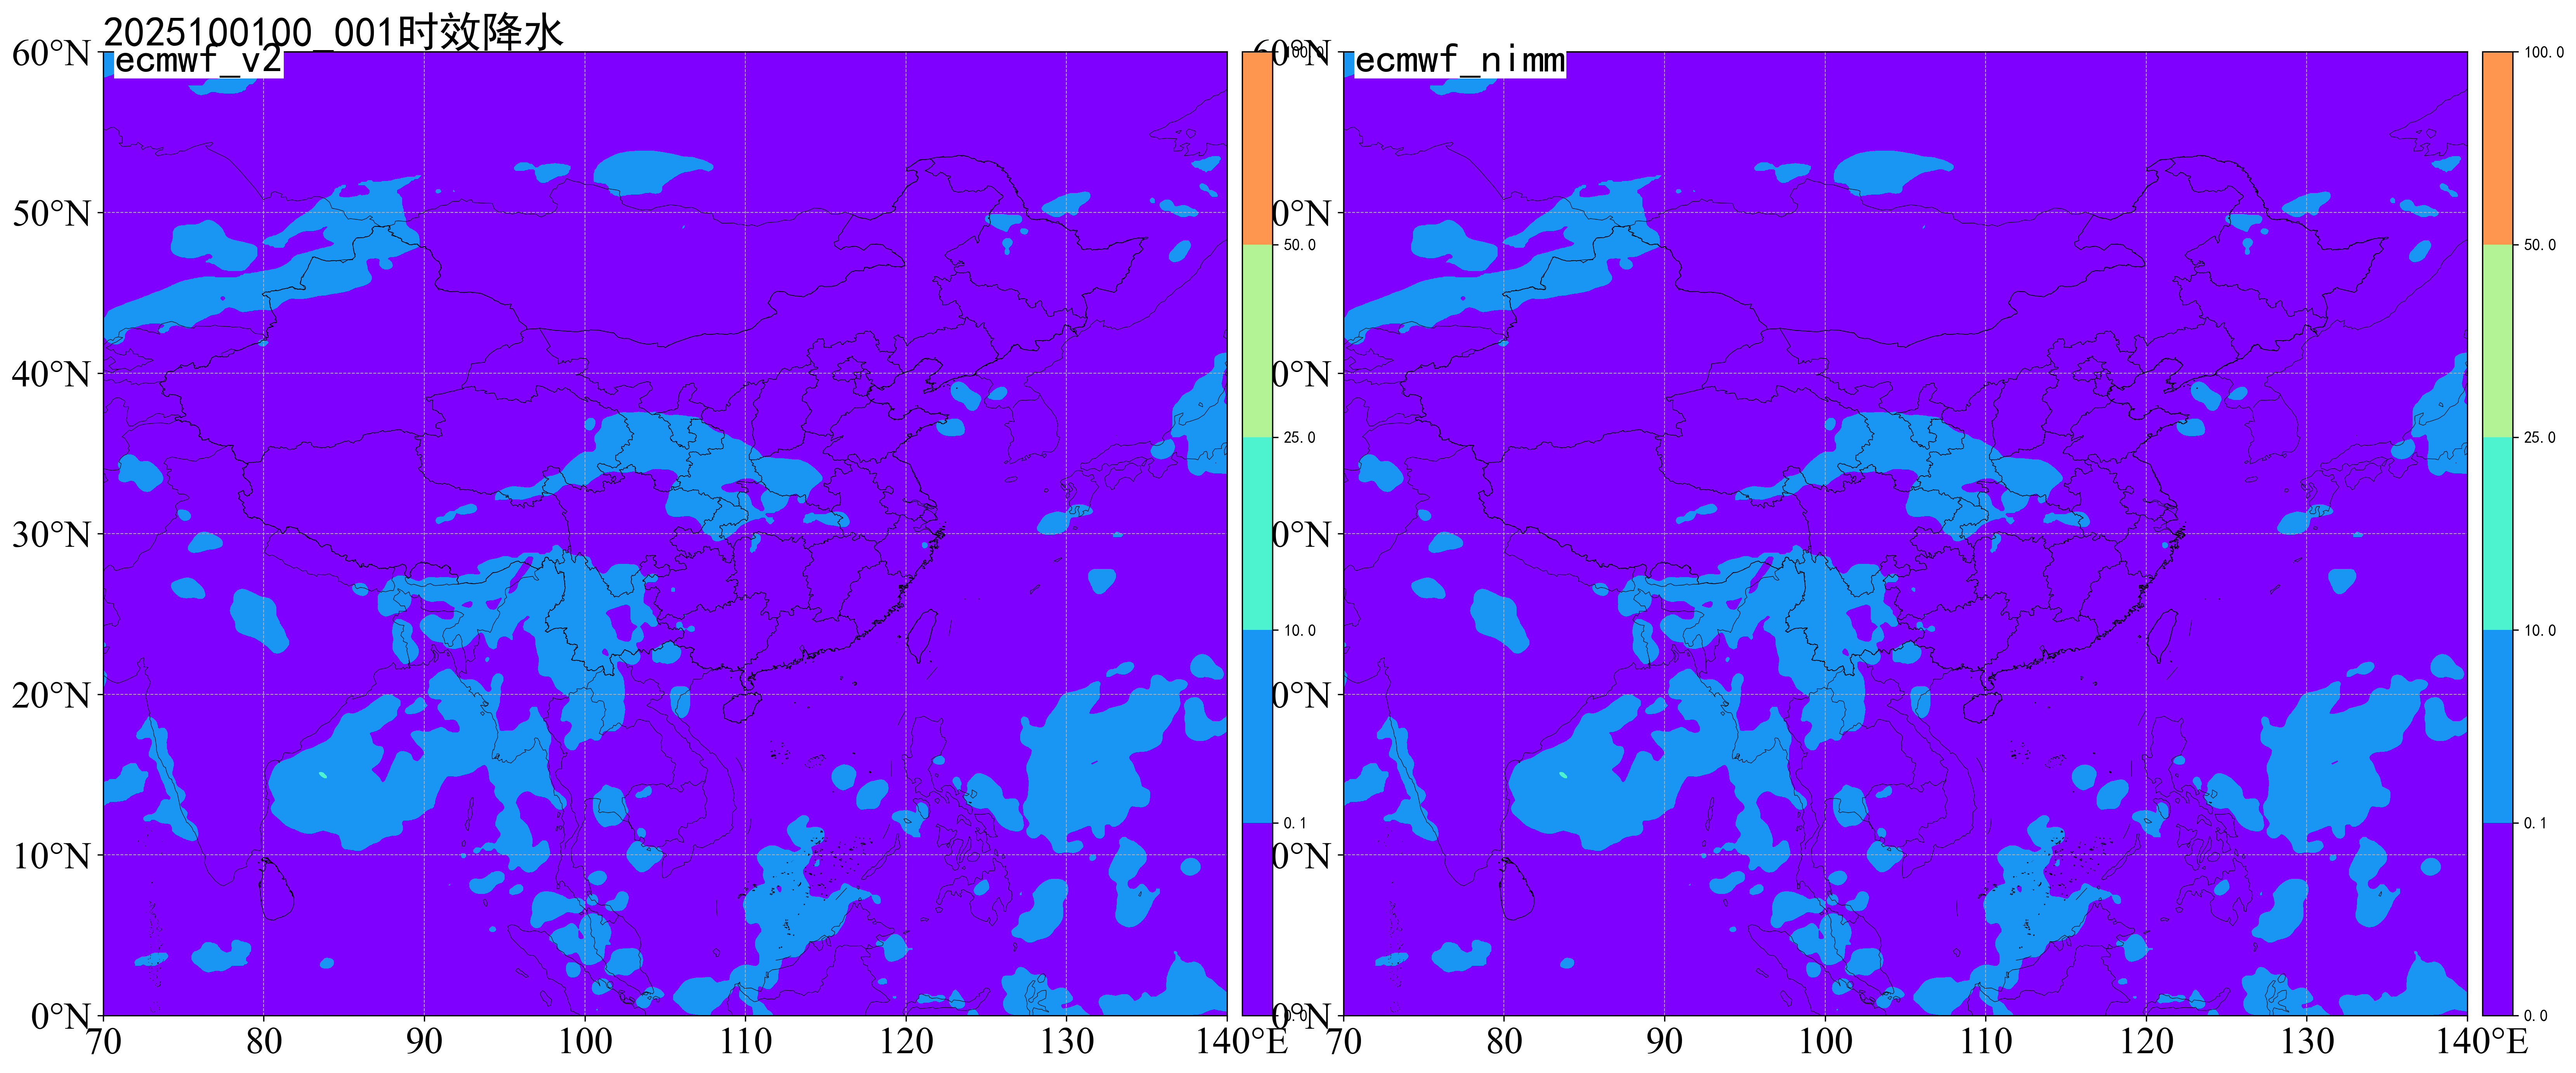

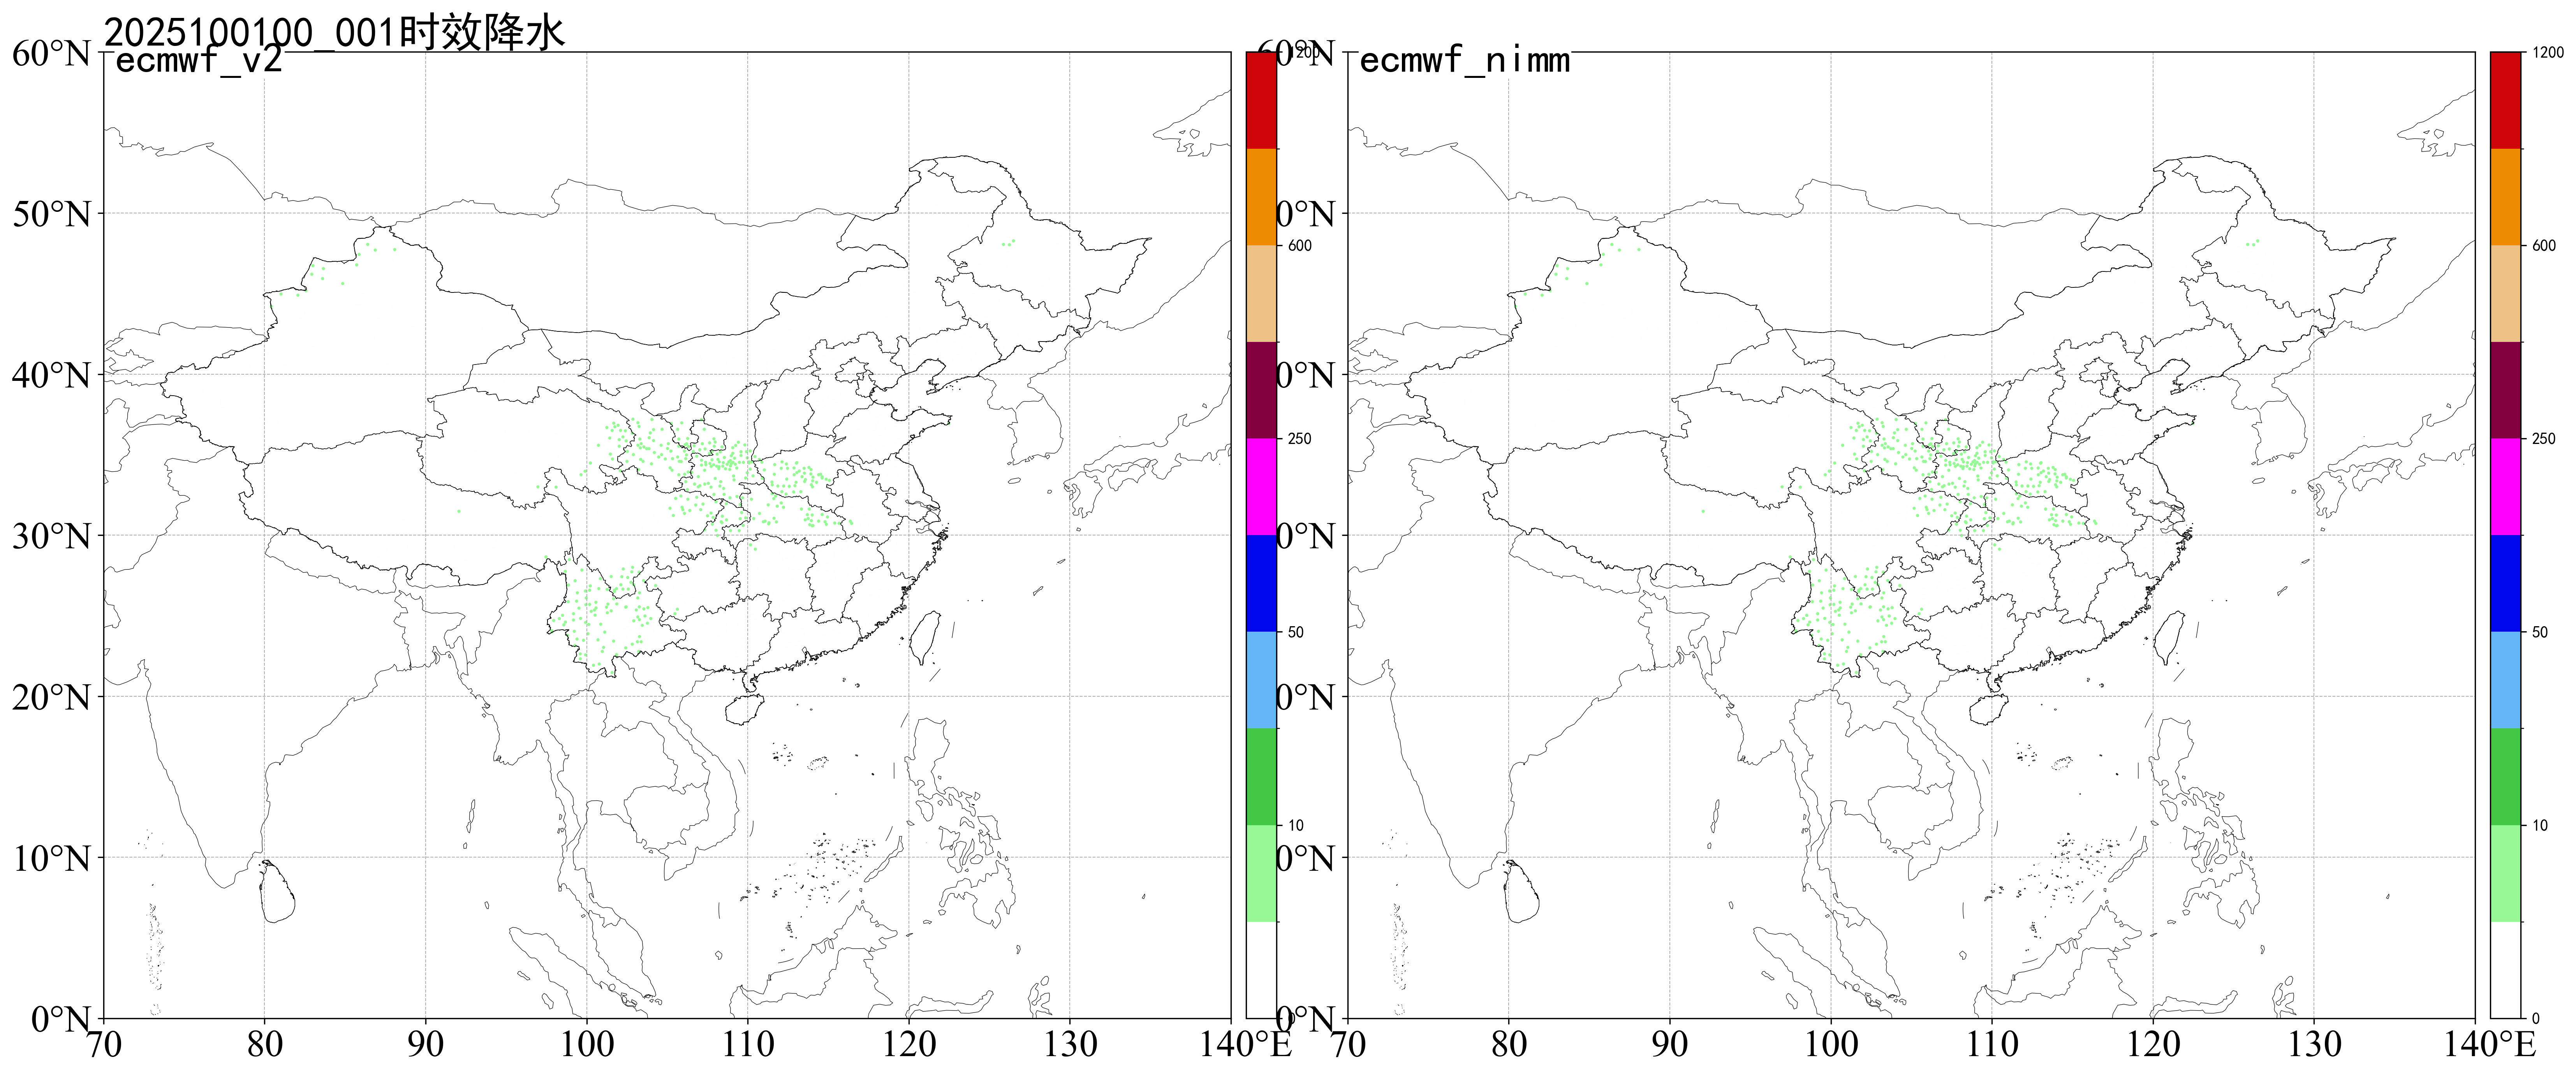

In [1]:
import meteva_base as meb
import numpy as np
import matplotlib.pyplot as plt
import datetime


ecmwf_v2 = r'D:/Work/QpfFrequencyMatch_Rain01/output/rain01/ecmwf_V2/YYYYMMDD/YYYYMMDDHH.TTT.m4'
ecmwf_nimm = r'D:/Work/qpf_fm_rain01/resource/data/output/rain01/ecmwf_nimm/YYYYMMDD/YYYYMMDDHH.TTT.m4'
png_dir = r'D:/Work/qpf_fm_rain01/resource/data/output/pngs/YYYYMMDD'
dtime = 1
ftime = '2025100100'

fo_time = datetime.datetime.strptime(ftime, '%Y%m%d%H')
ec_2_path = meb.get_path(ecmwf_v2, fo_time, dtime)
ec_1_path = meb.get_path(ecmwf_nimm, fo_time, dtime)
pg_path = meb.get_path(png_dir, fo_time)

ec1_grd = meb.read_griddata_from_micaps4(ec_2_path)
ec2_grd = meb.read_griddata_from_micaps4(ec_1_path)

map_extend = [70.0, 140.0, 0, 60.0]
axs = meb.creat_axs(2, map_extend, ncol=2, add_index=['ecmwf_v2', 'ecmwf_nimm'],
                    sup_title=f'{ftime}_{dtime:03d}时效降水', sup_fontsize=26, wspace=1, height=26, width=26)
clevs = np.array([0, 0.1, 10, 25, 50, 100])
meb.add_contourf(axs[0], ec1_grd, cmap='rainbow', clevs=clevs, add_colorbar=True)
meb.add_contourf(axs[1], ec2_grd, cmap='rainbow', clevs=clevs, add_colorbar=True)

# plt.savefig(f"{pg_path}/{ftime}_{dtime:03d}_1.png", bbox_inches='tight')


ecmwf_v2 = r'D:/Work/QpfFrequencyMatch_Rain01/output/rain01/ecmwf_V2/YYYYMMDD/YYYYMMDDHH.TTT.m3'
ecmwf_nimm = r'D:/Work/qpf_fm_rain01/resource/data/output/rain01/ecmwf_nimm/YYYYMMDD/YYYYMMDDHH.TTT.m3'
dtime = 1
ec_2_path = meb.get_path(ecmwf_v2, fo_time, dtime)
ec_1_path = meb.get_path(ecmwf_nimm, fo_time, dtime)

ec1_sta = meb.read_stadata_from_micaps3(ec_2_path)
ec2_sta = meb.read_stadata_from_micaps3(ec_1_path)

axs = meb.creat_axs(2, map_extend, ncol=2, add_index=['ecmwf_v2', 'ecmwf_nimm'],
                    sup_title=f'{ftime}_{dtime:03d}时效降水', sup_fontsize=26, wspace=1, height=26, width=26)
meb.add_scatter(axs[0], ec1_sta, cmap=meb.cmaps.rain_24h, add_colorbar=True, alpha=1)
meb.add_scatter(axs[1], ec2_sta, cmap=meb.cmaps.rain_24h, add_colorbar=True, alpha=1)

# plt.savefig(f"{pg_path}/{ftime}_{dtime:03d}_2.png", bbox_inches='tight')

## 9.结果检验对比

        level                time  dtime     id     lon    lat        ob  \
0           0 2025-10-01 08:00:00      1  50136  122.52  52.97       0.0   
1           0 2025-10-01 08:00:00      1  50137  122.37  53.47       0.0   
2           0 2025-10-01 08:00:00      1  50246  124.72  52.35       0.0   
3           0 2025-10-01 08:00:00      1  50247  123.57  52.03       0.0   
4           0 2025-10-01 08:00:00      1  50349  124.40  51.67       0.0   
...       ...                 ...    ...    ...     ...    ...       ...   
115723      0 2025-10-01 08:00:00     48  59945  109.70  18.65  999999.0   
115724      0 2025-10-01 08:00:00     48  59948  109.58  18.22  999999.0   
115725      0 2025-10-01 08:00:00     48  59951  110.33  18.80  999999.0   
115726      0 2025-10-01 08:00:00     48  59954  110.03  18.55  999999.0   
115727      0 2025-10-01 08:00:00     48  59981  112.33  16.83  999999.0   

        QpfFrequencyMatch_Rain01  qpf_fm_rain01  
0                            0.0     

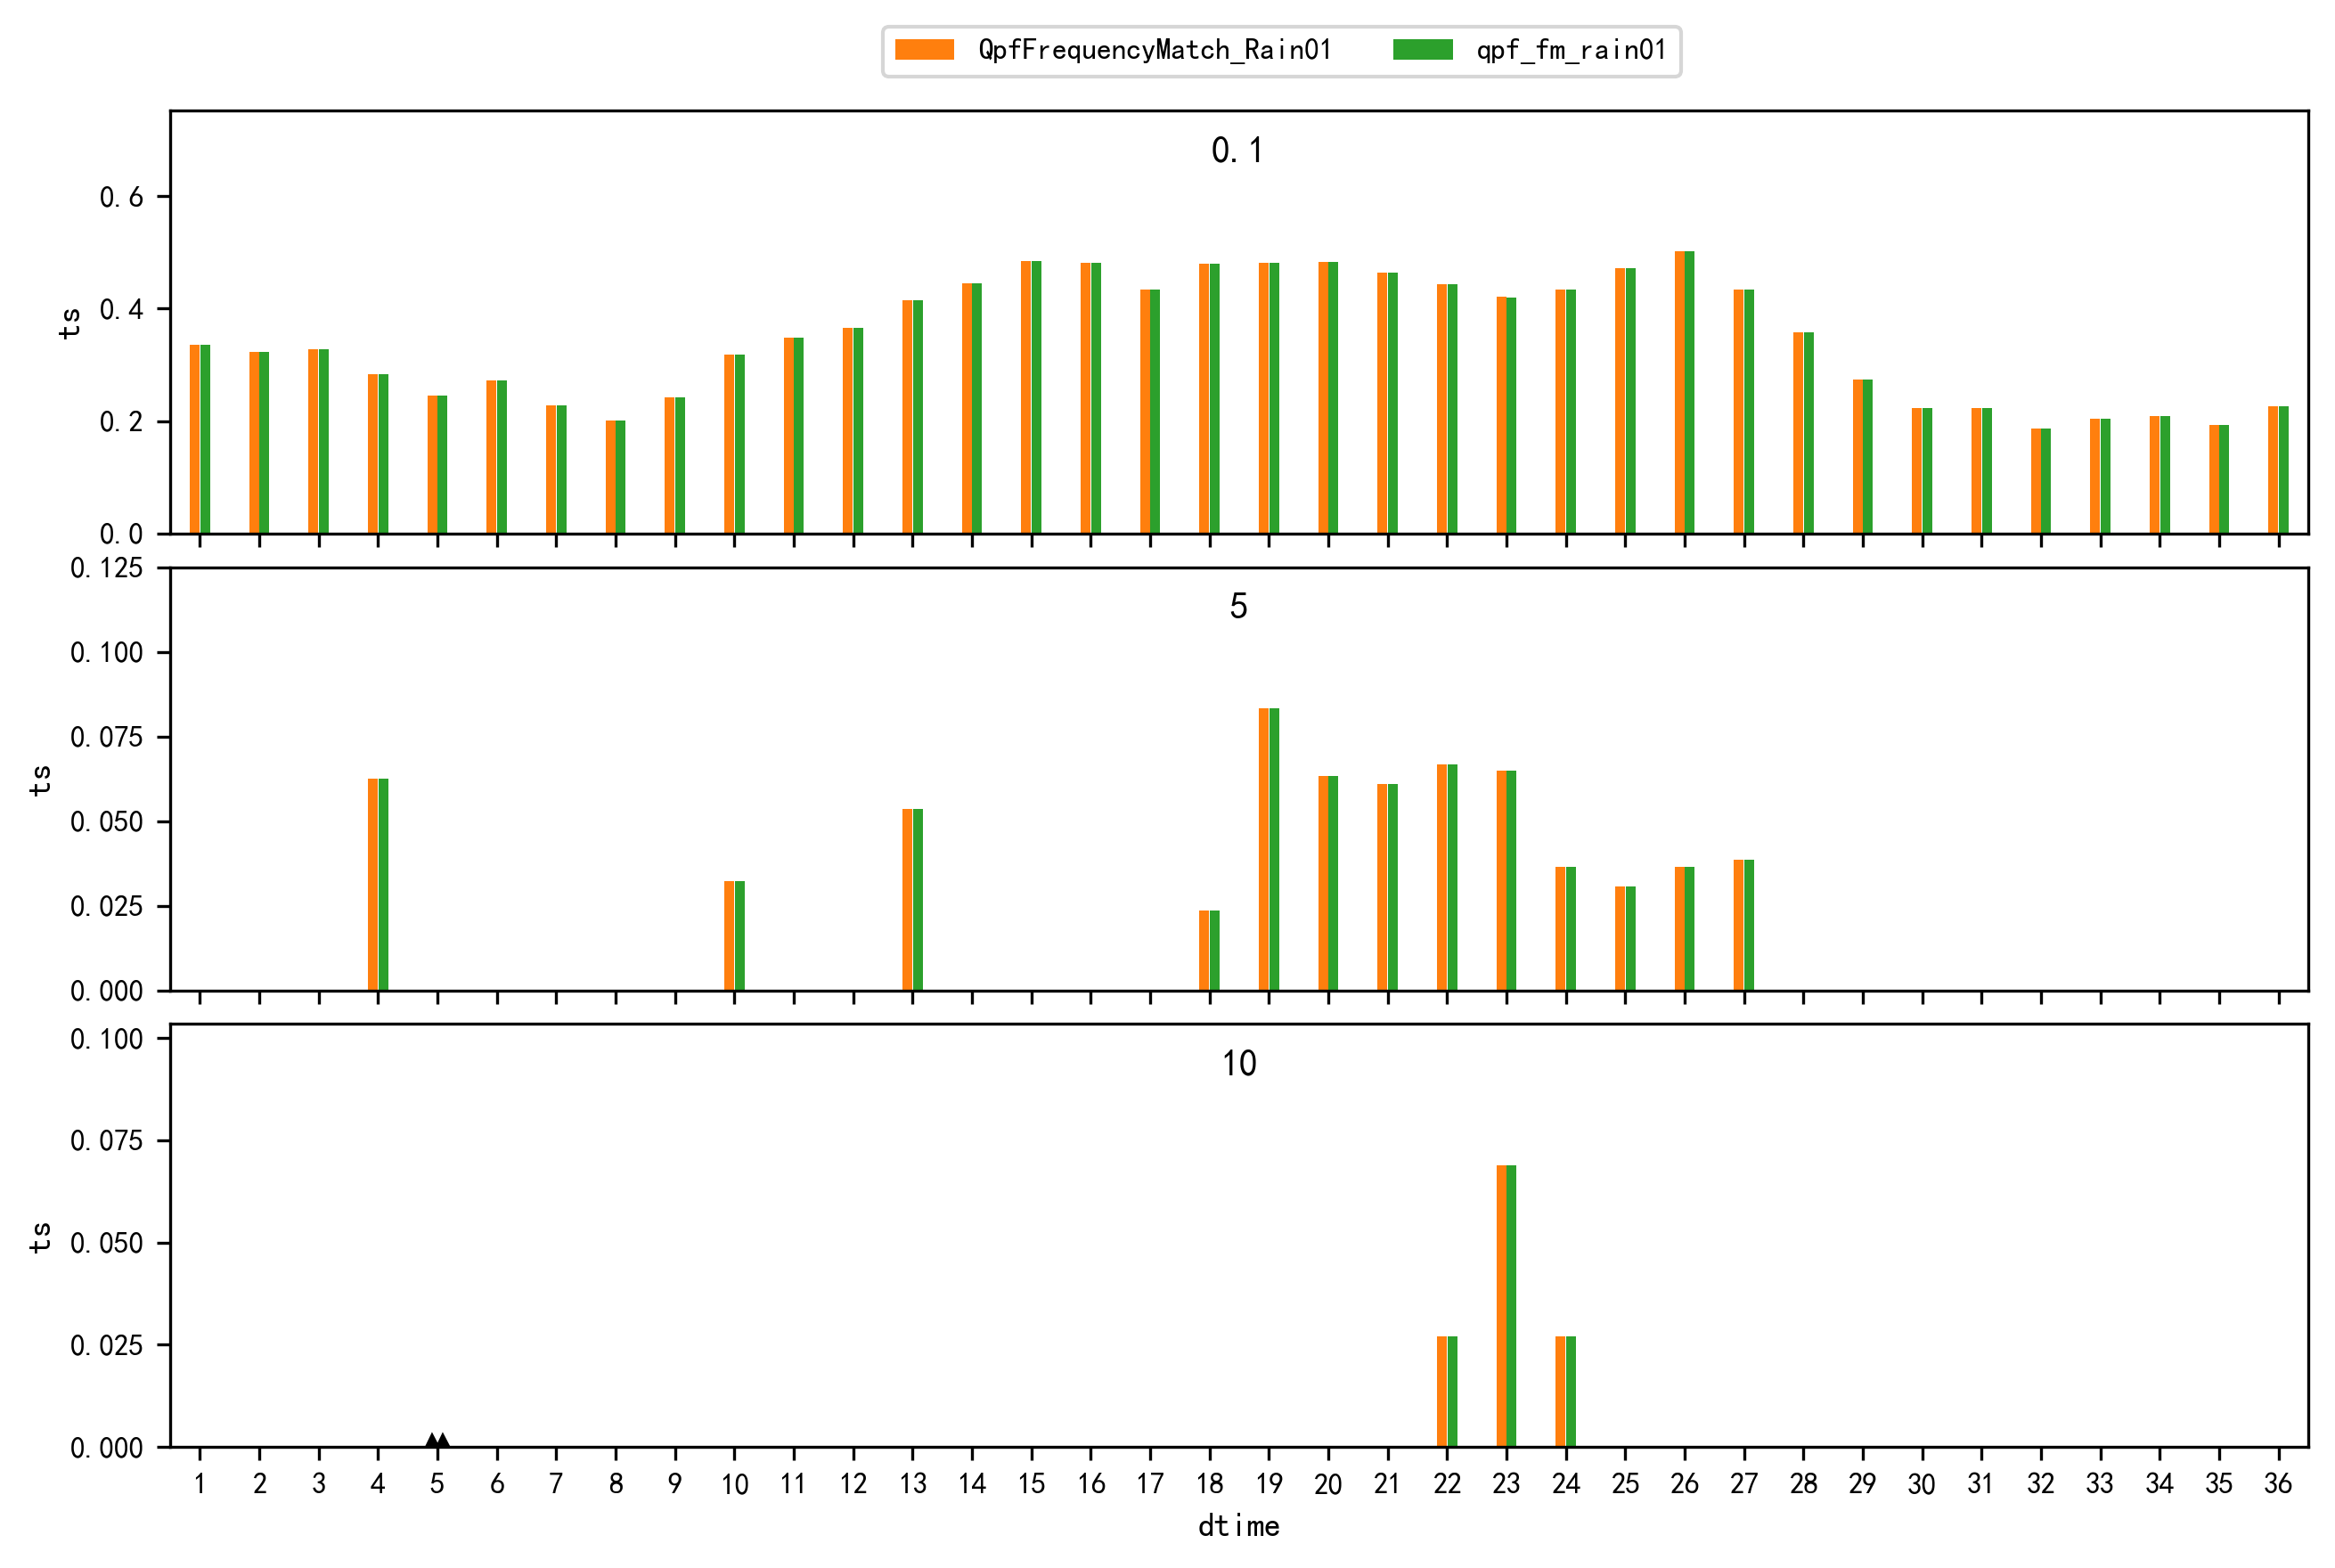

In [2]:
import meteva
import pandas as pd
import meteva_base as meb

import meteva.method as mem
import meteva.product as mpd


from datetime import datetime

h5_file = "D:/Work/qpf_fm_rain01/resource/data/output/verify_data.h5"

sta_all = pd.read_hdf(h5_file, key="sta_all")
print(sta_all)
product_list = ["QpfFrequencyMatch_Rain01", "qpf_fm_rain01"]
grade_list = [0.1, 5, 10]
# get_ts(sta_all, grade_list, product_list, h5_file)  # 保存ts评分结果
result = mpd.score(sta_all, mem.ts, grade_list=grade_list, g="dtime", plot="bar", ncol=1, save_path=f"ts_bar.png", show=True)